![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_2/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller: Reconocimiento facial con K-medias y K-medoides

En este caso-taller vamos a aplicar K-medias y K-medoides para agrupar rostros de indiviudos. Utilizaremos la base de datos conocida como Caras Olivetti. Esta base contiene diez imágenes diferentes de  40 personas distintas. Para algunas personas, las imágenes se tomaron en diferentes momentos, variando la iluminación, las expresiones faciales (ojos abiertos/cerrados, sonriendo/sin sonreír) y los detalles faciales (gafas/sin gafas). Todas las imágenes fueron tomadas contra un fondo homogéneo oscuro con los sujetos en una posición frontal erguida (con tolerancia a algún movimiento lateral). Esta base viene incluida dentro de la libraría `scikit-learn` y fueron provistas por T&T Laboratories Cambridge para que la comunidad académica la utilice para la evaluación de modelos predictivos.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

Los datos pueden ser bajados directamente utilizando la librería `scikit-learn`,  la función que le permite hacer esto es `fetch_olivetti_faces`.

In [1]:
# Utilice este espacio para escribir el código.

#### 1. Creamos una función (install_load) que revise si las librerías necesarias están instaladas, y si no lo están, las instala automáticamente.
import sys
import subprocess

def install_load(package):
    try:
        __import__(package)
        print(f'La librería {package} ya está instalada')
    except ImportError:
        print(f'La librería {package} no se encontró. Instalando la librería {package}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f'La librería {package} ha sido instalada\n')  


### a. La lista librerias_taller contiene los nombres de las librerías necesarias para este taller.
lista_taller = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']


### b. Construimos un loop-for para revisar cada libería contenida en lista_taller
for i in lista_taller:
    install_load(i)

### c. Librerías usadas en la primera parte del Taller 1

import os                                               ##  Manejos de rutas y directorios
import numpy as np                                      ##  Computación científica 
import pandas as pd                                     ##  Manejo y manipulación de datos 
import matplotlib.pyplot as plt                         ##  Gráficos básicos 
import seaborn as sns                                   ##  Gráficos estadísticos 

from sklearn.datasets import fetch_olivetti_faces       ## Base de datos con los rostros humanos
from sklearn.preprocessing import StandardScaler        ## Función para estandarizar datos
from sklearn.cluster import KMeans                      ## Función para implementar clusters con KMeans 
from sklearn.decomposition import PCA                   ## Función para implementar el PCA
from sklearn_extra.cluster import KMedoids     ## Función para implementar K-Medoides
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score ## Funciones para evaluar las métricas de los modelos de clusterización

### d. Cambiamos el estilo de los gráficos de matplotlib a ggplot2 del lenguaje R
plt.style.use('ggplot')  


#### 2. Cargamos el dataset con los rostros humanos

### a. Fijamos la ruta del directorio en GitHub (carpeta de data) donde guardamos la base de datos con los rostros humanos
data_path = os.path.join('..', 'data')

### b. Cargamos la base de datos con los rostros sin orden (shuffle = True) y con la semilla aleatoria igual 
faces = fetch_olivetti_faces(shuffle = True, 
                             data_home = data_path,
                             random_state = 36)


La librería pandas ya está instalada
La librería numpy ya está instalada
La librería matplotlib ya está instalada
La librería seaborn ya está instalada
La librería scikit-learn no se encontró. Instalando la librería scikit-learn
La librería scikit-learn ha sido instalada



(Utilice este espacio para describir su procedimiento).

**- Función install_load():** el primer paso consiste en la implementación de la función install_load() que se encarga de revisar si en nuestro kernel de Python están instaladas las librerías que están registradas en el objeto *lista_taller*, en caso de que no estén registradas en el sistema, la función se encarga de instalarlas mediante la librería *pip* a través de un loop-for.

**- Librerías:** para el desarrollo de este taller vamos a usar las librerías os, Numpy, Pandas, Matplotlib, Seaborn y Sklearn.

**- Estilo de gráficas:** con la función *plt.style.use()* fijamos que el estilo de las gráficas sea el de la librería *ggplot2* del lenguaje de programación R.

**- Ruta para almacenar los archivos:** definimos el objeto *data_path* como la ruta, en el repositorio de GitHub, que va a contener el archivo de los rostros en la carpeta de *data*.

**- Cargando el dataset de los rostros de Olivetti:** a través de la librería *sklearn*, obtenemos el dataset de Olivetti. Para esto importamos la función *fetch_olivetti_faces()* que nos permite descargar los datos y fijarle parámetros para que los rostros estén sin orden predeterminado, fijar el directorio donde se guardan los datos o fijar una semilla (36) para facilitar la reproducibilidad del ejercicio.



### 2.  Análisis preliminar

#### 2.1. Describa los contenidos de la base de datos, tenga en cuenta que debe detallar los elementos, la dimensión de la base, y la dimensión de las imágenes. Genere una figura con una imagen de cada uno de los individuos

In [2]:
# Utilice este espacio para escribir el código.

#### 1. Contenido de la base de datos con los rostros de Olivetti  

### a. Exploramos los componentes del dataset( faces) a traves de las keys() y un loop-for para mostrar cada componente.
print('Componentes del dataset de los rostros humanos de Olivetti:')

for llave in faces.keys():
    if llave == 'DESCR':
        print(f'- {llave} Contiene la descripción del dataset')
    else:
        print(f'- {llave}: Dimensiones {faces[llave].shape}')    


Componentes del dataset de los rostros humanos de Olivetti:
- data: Dimensiones (400, 4096)
- images: Dimensiones (400, 64, 64)
- target: Dimensiones (400,)
- DESCR Contiene la descripción del dataset


(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

**- Introducción:** para poder explorar todos los componentes del objeto *faces*, usamos la función keys() que nos permite desglosar todos los componentes del dataset, sin embargo, también aplicamos un loop-for para poder mostrar uno a uno los elementos con su respectivo tamaño.

**- Componentes del dataset:** a continuación describimos cada uno de los componentes que obtenemos con keys()

**data:** es la matriz principal del dataset que contiene las 400 imágenes (filas) y 4096 columnas que corresponden a un píxel aplanado.

**images:** corresponde a las imágenes originales (400), pero con su forma original en la que tiene 64 pixeles de ancho y de alto.

**target:** es la lista con las etiquetas (y), por lo que es un vector con 400 números de las cuarenta personas que son representadas en las imágenes (0 a 39).

**DESCR:** es un texto con una descripción del dataset de imágenes.

#### 2.2. Genere una figura con una imagen de cada uno de los individuos

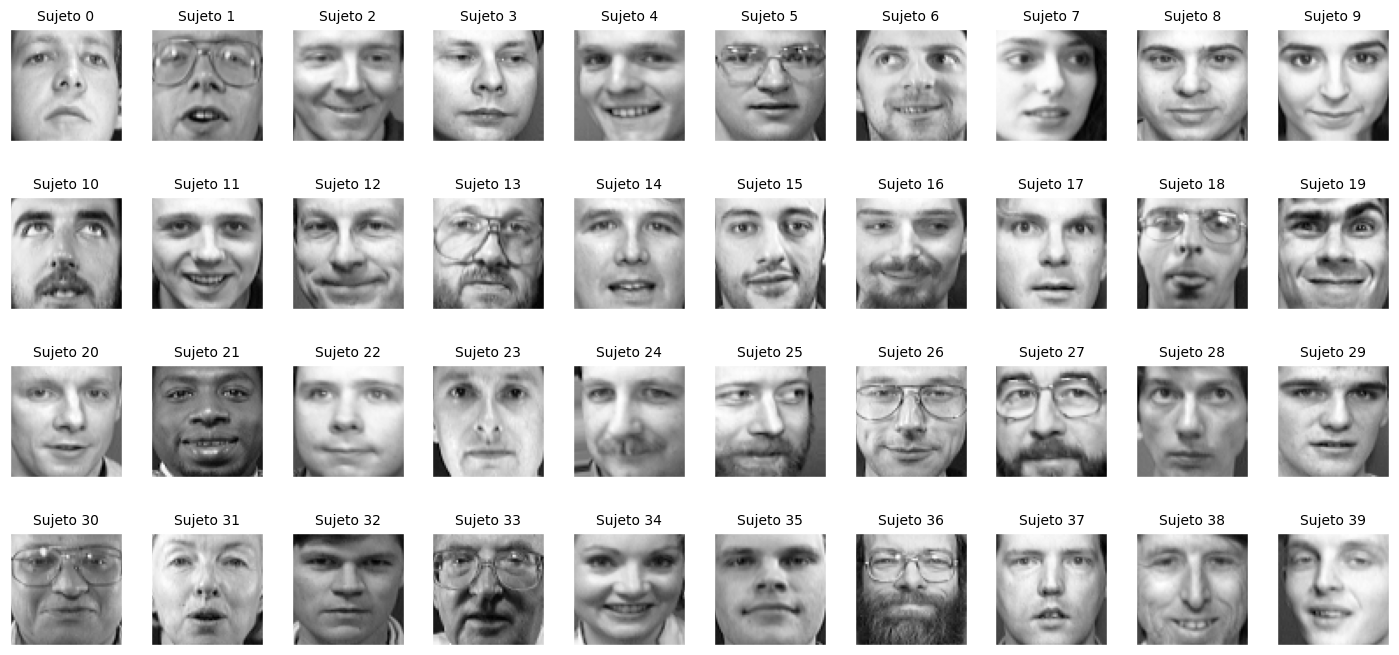

In [3]:
# Utilice este espacio para escribir el código.

#### 1. Visualización de los rostros humanos

### a. Construyendo un subplot (Matplotlib) de tamaño 4x10, que retire los ejes 
fig, axes = plt.subplots(4, 10, 
                         figsize = (18, 8), 
                         subplot_kw = {'xticks': [], 'yticks': []}, 
                         gridspec_kw = dict(hspace = 0.5, 
                                            wspace = 0.1))


### b. Mediante un loop-for iteramos sobre los cuarenta rostros humanos
for i, ax in enumerate(axes.flat):
    primera_imagen = np.where(faces.target == i)[0][0]
    rostro = faces.images[primera_imagen]
    ax.imshow(rostro, cmap = 'gray')
    ax.set_title(f'Sujeto {i}', fontsize = 10)

plt.show()


(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

**Construcción del subplot:** para generar los rostros humanos es necesario construir un subplot, de la librería Matplotlib, que es configurado para que tenga el tamaño de cuatro filas y 10 columnas, que serán ubicadas en el array *axes* (de tamaño 40) a través de un loop-for. Además, creamos dos listas vacías (xticks e yticks) para eliminar los números y guiones que hay en los bordes,

**Loop-for:** este blucle nos permite recorrer el array de *axes* (aplanado con .flat que lo convierte en una lista) mediante la función *enumerate()*. En la segunda línea buscamos, con *np.where*, los *i* que están en target y con los corchetes buscamos la primera lista y en la segunda lista sacamos el primer número.

Posteriormente, extraemos las fotos específicas en *images*, mediante el objeto *primera_imagen* que construímos en el paso anterior. Con la función *ax.imshow()* dibujamos la matriz con los rostros. 

#### 2.3. Transforme las imágenes en un data frame donde cada columna contiene los valores estandarizados del nivel de gris en la imagen y una columna con la etiqueta de cada imagen.

In [4]:
# Utilice este espacio para escribir el código.

#### 1. Estandarización de los datos de data (matriz X)

### a. Guardamos la matriz faces.data en el objeto X
X = faces.data

### b. El objeto scaler va a contener la función de estandarización StandardScaler()
scaler = StandardScaler()

### c. Estandarizamos la matriz X y guardamos la matriz estandarizada en el objeto X_standard
X_standard = scaler.fit_transform(X)

### Ahora, es necesario asignar un nombre a cada una de las 4096 columnas, en la lista col_names
col_names = []

for i in range(X.shape[1]):
    name = f'pixel_{i+1}'
    col_names.append(name)

### Construímos el DataFrame de la matriz estandarizada con la librería Pandas
df_faces = pd.DataFrame(X_standard, 
                        columns = col_names)

### Agregamos la columna y al final del DataFrame
df_faces.insert(0, 'person', faces.target)

### Visualizamos las primeras cinco filas del DataFrame
df_faces.head()


,person,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,pixel_4096
0,6,-1.003642,-1.202663,-1.386484,-1.679522,-1.980421,-2.074087,-2.460646,-2.500667,-2.575374,...,0.053551,0.276018,0.094487,0.328160,0.970998,1.247088,1.455763,1.436481,0.047263,-0.575599
1,33,0.461779,0.063643,-0.069260,-0.159932,-0.313114,-0.706391,-0.603741,-0.418946,-0.389172,...,-0.673843,-0.292740,-0.042203,-0.022637,0.170587,1.225226,1.519324,1.810923,1.962558,1.989744
2,13,1.263182,1.417280,1.226718,1.081424,1.156749,1.148111,1.055093,1.048934,1.096324,...,-0.749090,-0.952499,-1.112942,-1.316203,-1.363532,-1.288843,-1.298555,-1.316769,-1.237112,-1.216934
3,18,-0.820464,-1.071666,-1.025310,-0.523777,-0.642187,0.452673,1.277921,1.369198,1.404635,...,0.931440,0.776525,-0.520618,-1.140804,-0.941093,-0.895337,-0.832439,-0.744093,-0.763921,-0.735933
4,14,0.805238,0.653130,0.589351,0.439343,0.366972,0.197678,0.163779,0.194894,0.059280,...,0.580285,0.435270,0.458994,0.350085,0.281755,0.219598,0.184539,0.048843,-0.989250,-0.713028


(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

**Definiendo la matriz X:** tomamos la matriz base a partir del componente faces.data (descrito anteriormente) y la guardamos en el objeto X.

**Estandarización de la matriz X:** usamos la función scaler.fit_transform() para estandarizar la matriz X y guardamos en el objeto X_standard.

**Lista de nombres para 4096 columnas:** con un loop-for creamos los nombres de las columnas del DataFrame con el prefijo 'pixel_' y lo replicamos 4096 veces en la lista bautizada como *col_names*.

**Creación del DataFrame:** con la función pd.DataFrame(), creamos el DataFrame df_faces que contiene los datos de X_standard y ajustamos el parámetro *columns* para que contenga nuetra lista de nombres *col_names*.

**Insertamos las etiquetas en la primera columna:** ubicamos las etiquetas (faces.target) como la primera columna. Este vector representa el eje *y* de los datos.

### 3. Clasificando de forma no supervisada

En esta sección trataremos de clasificar las imágenes de los individuos de forma no supervisada. Para ello utilizaremos los algoritmos de k-medias y k-medoides. Dado que sabemos que el dataset consta de 40 personas diferentes, utilizaremos esta información para pedirle a los algoritmos encuentren k=40 clusters y examinaremos su precisión .


#### 3.1. Implemente k-medias sobre los datos estandarizados en el punto anterior. Al implementar utilice  `random_state=123` y `n_init=10`. (Esto puede tomar mucho tiempo y requerir mucho RAM, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [5]:
# Utilice este espacio para escribir el código.

#### 1. Implementación del algoritmo K-means para implementar los cluster 

### a. Usamos la función KMeans(), de la librería scikit-learn, para hacer los clusters
kmeans_c = KMeans(n_clusters = 40, 
                  random_state = 123, 
                  n_init = 10)

### b. Entrenamos el modelo con la matriz estandarizada
kmeans_c.fit(X_standard)

### c. Guardamos las predicciones en el objeto kmeans_tags
kmeans_tags = kmeans_c.labels_

### d. Agregamos el vector de predicciones al DataFrame
df_faces['cluster_kmeans'] = kmeans_tags

### e. Agrupamos los cluster por su respectiva media
df_faces.groupby('cluster_kmeans').mean().head()


,person,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,pixel_4096
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,27.000000,0.764023,0.753561,0.534113,0.345172,0.292382,0.577851,0.654002,0.637927,0.608633,...,-1.115295,-1.216403,-1.204068,-1.101339,-1.056708,-1.057112,-0.921425,-0.774930,-0.646750,-0.612247
1,17.450000,-0.493034,-0.688499,-0.802232,-0.669316,-0.554434,-0.439807,-0.254643,-0.176079,-0.162143,...,0.438568,0.400007,0.469245,0.509040,0.593026,0.593430,0.586034,0.696407,0.701843,0.712799
2,17.176471,0.995150,0.945947,0.865543,0.788081,0.701208,0.608123,0.564288,0.471201,0.433539,...,-0.814010,-0.832056,-0.961510,-0.993779,-0.849543,-0.793745,-0.767632,-0.740206,-0.702950,-0.618714
3,21.000000,-1.266960,-1.202663,-1.161281,-1.125193,-1.131410,-1.112064,-1.143481,-1.230284,-1.358949,...,-0.989882,-0.677220,-0.543400,-0.290120,-0.340786,-0.110510,0.021399,-0.224280,-0.123987,-0.298450
4,28.500000,0.459490,0.653130,0.871917,0.520674,0.042286,0.385447,0.814933,1.080960,1.048676,...,-0.909618,-0.927474,-1.103829,-0.932518,-0.821032,-0.792588,-0.834558,-0.774930,-0.741388,-0.667218


(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

**Agrupamiento por KMeans:** usamos la función KMeans(), de la librería sk-learn, para iniciar la implementación de del algoritmo de K-medias para agrupar por clusters. Le indicamos que nos cree 40 clusters, fijamos la semilla en el valor 123 y 10 inicializaciones aleatorias.

**Entrenamiento del modelo:** realizamos el entrenamiento de K-mean con la matriz estandarizada (X_standard)

**Predicciones:** guardamos las predicciones en el objeto *kmeans_tags* y este vector lo añadimos como una nueva columna a nuestro DataFrame *df_faces*.


#### 3.2. Evalúe la precisión del algoritmo para agrupar las imágenes de los individuos.

In [6]:
# Utilice este espacio para escribir el código.

#### 1. Métricas de evaluación para el algoritmo de K-means para clusters

### a. Es necesario extraer, y guardar en un objeto, las etiquetas predichas (predicciones) y las etiquetas reales
real_tags = df_faces['person']

fitted_tags = df_faces['cluster_kmeans']

### b. Métricas necesarias para evaluar el comportamiento del K-means
ari = adjusted_rand_score(real_tags, fitted_tags)
homogeneidad = homogeneity_score(real_tags, fitted_tags)
completitud = completeness_score(real_tags, fitted_tags)
v_measure = v_measure_score(real_tags, fitted_tags)

### c. Hacemos los print() correspondientes para mostar los resultados de las métricas
print("=== Resultados de las métricas ===")
print(f"Homogeneidad : {homogeneidad:.2f}  (Si es igual a 1: cada clúster tiene fotos de una sola persona)")
print(f"Completitud  : {completitud:.2f}  (Si es igual a 1: todas las fotos de una persona quedaron en el mismo clúster)")
print(f"V-Measure    : {v_measure:.2f}  (Media equilibrada entre homogeneidad y completitud)")
print("-" * 50)
print(f"Adjusted Rand Index (ARI): {ari:.2f} (Escala: -1.0 a 1.0)")


=== Resultados de las métricas ===
Homogeneidad : 0.76  (Si es igual a 1: cada clúster tiene fotos de una sola persona)
Completitud  : 0.79  (Si es igual a 1: todas las fotos de una persona quedaron en el mismo clúster)
V-Measure    : 0.77  (Media equilibrada entre homogeneidad y completitud)
--------------------------------------------------
Adjusted Rand Index (ARI): 0.42 (Escala: -1.0 a 1.0)


(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

**Objetos de las etiquetas:** en primer lugar, es necesario crear dos objetos, a partir del DataFrame *df_faces*, que contengan las etiquetas predichas (fitted_tags) y las reales (real_tags). 

**Usamos las siguientes métricas:**

- **Homogeneidad:** mide la pureza de cada clúster implementado, lo ideal es que los clústers contengan únicamente la foto de la misma persona, esto implica que sean homogéneos. El resultado de esta métrica la guardamos en el objeto *homogeneidad*. Un valor igual a 1, nos indica que la homogeneidad es perfecta. 

- **Completitud:** muestra que tan juntos quedaron los datos clusterizados, el caso perfecto es cuando todas las fotos de la misma persona quedaron en el clúster. El resultado de esta métrica la guardamos en el objeto *completitud*. Un valor igual a 1, nos indica que la completitud es perfecta. 

- **V-Measure:** corresponde a la media armónica entre homogeneidad y completitud. Un valor de 1 indica que la homogeneidad y completitud son perfectas al tiempo. El resultado de esta métrica la guardamos en el objeto *v_measure*.

- **Adjusted Rand Index (ARI):** mide la similitud general entre agrupaciones, castigando el factor suerte. El resultado de esta métrica la guardamos en el objeto *ari*


**Interpretación de las métricas resultantes:** aunque la **Homogeneidad** y **Completitud** tienen valores altos, el **ARI** tiene un valor igual a 0.42 y esto nos indica que el algoritmo no está agrupando adecuadamente. Este problema puede ser causado por el exceso de dimensiones en la matriz estandarizada (problema de una elevada dimensionalidad), en el siguiente punto implementaremos un Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de los datos a través de los componentes y poder implementar una mejor clusterización de los datos.



#### 3.3. Usando PCA reduzca la dimensión de la matriz de predictores. Retenga el numero de componentes que explican el 95% de la varianza y vuelva a utilizar k-medias para clasificar las imágenes comentado si la precisión mejoró.

In [7]:
# Utilice este espacio para escribir el código.

#### 1. Implementando la reducción de dimensionalidad mediante el PCA

### a. Creamos un PCA que retenga el 95% de la varianza (n_components) y con una semilla igual a 123 
pca = PCA(n_components = 0.95, 
          random_state = 123)

### b. Aplicamos el PCA a nuestra matriz estandarizada y guardamos el resultado en el objeto X_pca
X_pca = pca.fit_transform(X_standard)

### c. Implementamos de nuevo KMeans con los parámetros indicados anteriormente
kmeans_pca = KMeans(n_clusters = 40, 
                    n_init = 10, 
                    random_state = 123)

### d. Entrenamos el modelo con la matriz estandarizada PCA
kmeans_pca.fit(X_pca)

### e. Extraemos las predicciones del modelo entrenado por PCA
etiquetas_kmeans_pca = kmeans_pca.labels_

### f. Añadimos la nueva columna de predicciones con PCA al DataFrame original
df_faces['cluster_kmeans_pca'] = etiquetas_kmeans_pca

### g. Creamos las métricas del PCA con las mismas funciones usadas en el paso previo
ari_pca = adjusted_rand_score(real_tags, etiquetas_kmeans_pca)
homogeneidad_pca = homogeneity_score(real_tags, etiquetas_kmeans_pca)
completitud_pca = completeness_score(real_tags, etiquetas_kmeans_pca)
v_measure_pca = v_measure_score(real_tags, etiquetas_kmeans_pca)

### h. Imprimimos los resultados de las nuevas métricas con PCA
print("\n=== Resultados Comparativos: K-Medias Puro vs K-Medias con PCA ===")
print(f"Métrica        | Puro (4096 var) | Con PCA ({X_pca.shape[1]} var)")
print("-" * 55)
print(f"Homogeneidad   | 0.76          | {homogeneidad_pca:.2f}")
print(f"Completitud    | 0.79          | {completitud_pca:.2f}")
print(f"V-Measure      | 0.77          | {v_measure_pca:.2f}")
print(f"ARI            | 0.42          | {ari_pca:.2f}")


=== Resultados Comparativos: K-Medias Puro vs K-Medias con PCA ===
Métrica        | Puro (4096 var) | Con PCA (123 var)
-------------------------------------------------------
Homogeneidad   | 0.76          | 0.77
Completitud    | 0.79          | 0.79
V-Measure      | 0.77          | 0.78
ARI            | 0.42          | 0.44


(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

**PCA:** creamos un Análisis de Componentes Principales (PCA), que retenga el 95% de la varianza, sobre la matriz estandarizada. Posteriormente, entrenamos el modelo para que haga predicciones sobre esta nueva matriz estandarizada con PCA (X_pca), extraemos las predicciones y las añadimos al DataFrame.

**Resultado de las métricas:** Las nuevas métricas muestran una leve mejoría, en particular podemos ver como el ARI solo tiene un pequeño incremento de 0.42 a 0.44, esto puede tener origen en la sensibilidad del algoritmo K-means frente a los datos atípicos. Esto será solventado en el siguiente paso al implementar los K-medoides.


#### 3.4. Utilice ahora el algoritmo por  K-medoides (use el mismo random state a los puntos anteriores), comente si mejoró la precisión total y para cada grupo de imágenes.

In [8]:
# Utilice este espacio para escribir el código.

#### 1. Implementando el modelo de los K-medoides con la librería sklearn

### a. Modelo de K-medoides con 40 clusters
kmedoids_model = KMedoids(n_clusters = 40, 
                          random_state = 123, 
                          init = 'k-medoids++', 
                          max_iter = 300)

### b. Entrenamos el modelo de K-medoides con la matriz estandarizada con PCA
kmedoids_model.fit(X_pca)

### c. Extraemos las predicciones del modelo entrenado por PCA
etiquetas_kmedoids_pca = kmedoids_model.labels_

### d. Añadimos la nueva columna de predicciones con PCA al DataFrame original
df_faces['cluster_kmedoids'] = etiquetas_kmedoids_pca


ari_kmedoids = adjusted_rand_score(real_tags, etiquetas_kmedoids_pca)
homogeneidad_kmedoids = homogeneity_score(real_tags, etiquetas_kmedoids_pca)
completitud_kmedoids = completeness_score(real_tags, etiquetas_kmedoids_pca)
v_measure_kmedoids = v_measure_score(real_tags, etiquetas_kmedoids_pca)


print("=== K-Medias vs K-Medoides (Ambos con PCA) ===")
print(f"Métrica        | PCA + K-Medias | PCA + K-Medoides")
print("-" * 55)
print(f"Homogeneidad   | {homogeneidad_pca:.2f}         | {homogeneidad_kmedoids:.2f}")
print(f"Completitud    | {completitud_pca:.2f}         | {completitud_kmedoids:.2f}")
print(f"V-Measure      | {v_measure_pca:.2f}         | {v_measure_kmedoids:.2f}")
print(f"ARI            | {ari_pca:.2f}         | {ari_kmedoids:.2f}")


=== K-Medias vs K-Medoides (Ambos con PCA) ===
Métrica        | PCA + K-Medias | PCA + K-Medoides
-------------------------------------------------------
Homogeneidad   | 0.77         | 0.72
Completitud    | 0.79         | 0.75
V-Measure      | 0.78         | 0.73
ARI            | 0.44         | 0.36


c:\Users\fevid\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

**K-Medoides con PCA:** entrenamos el modelo para que haga predicciones sobre esta nueva matriz estandarizada con PCA (X_pca), extraemos las predicciones y las añadimos al DataFrame.

**Resultado de las métricas:** las nuevas métricas muestran un empeoramiento en el ARI, en particular podemos ver como el ARI disminuye de 0.44 a 0.36. Lo anterior puede tener origen en el proceso de los K-Medoides, ya que al fijar una fotografía como centroide se heredan los sesgos de la foto, como: destellos o sombras y esto puede alterar los clústeres porque el algoritmo puede empezar a agrupar las imágenes por estos defectos.

### 4. Número de clusters óptimo

En el punto anteriores utilizamos nuestro conocimiento previo sobre los datos para elegir el número de clusters. En este punto, verifique si 40 es realmente el número de cluster que usted elegiría según los criterios estudiados en los cuadernos teóricos. Discuta los resultados obtenidos.

In [9]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones)